# Analiza podatkov Formule 1 (2021-2024)
V tej projektni nalogi sem analizirala rezultate dirkačev in ekip v svetovnem prvenstvu Formule 1 za zadnja štiri zaključena leta (2021, 2022, 2023, 2024). Podatke sem zajela z uradne spletne strani Formula 1. 
Cilj analize je ugotoviti prevlado posameznih dirkačev  in ekip, stabilnost rezultatov skozi sezone ter vpliv držav, iz katerih prihajajo dirkači.

## Priprava podatkov 
Najprej uvozimo knjižnici `pandas` in `matplotlib` ter naložimo tabelo `dirkaci_f1.csv`.

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

df = pd.read_csv("dirkaci_f1.csv")
df.head()

,sezona,mesto,dirkac,drzava,ekipa,tocke
0,2021,1,Max Verstappen,NED,Red Bull Racing Honda,395.5
1,2021,2,Lewis Hamilton,GBR,Mercedes,387.5
2,2021,3,Valtteri Bottas,FIN,Mercedes,226.0
3,2021,4,Sergio Perez,MEX,Red Bull Racing Honda,190.0
4,2021,5,Carlos Sainz,ESP,Ferrari,164.5


Zgoraj vidimo naložene osnovne podatke o dirkačih. Da bo analiza bolj poglobljena, bomo ustvarili dva nova stolpca:
- **`kategorija`**: uvrstitev dirkača glede na končni uspeh (Prvak, Top 3 - stopničke, Top 10 ali Izven top 10),
- **`delez_sezone_%`**: kolikšen delež vseh točk v tistem letu je osvojil posamezen dirkač.

In [2]:
def doloci_kategorijo(mesto):
    if mesto == 1:
        return "Prvak (1. mesto)"
    elif mesto <= 3:
        return "Top 3 (Stopničke)"
    elif mesto <= 10:
        return "Top 10 (točke)"
    else:
        return "Izven top 10"
    
df["kategorija"] = df["mesto"].apply(doloci_kategorijo)

skupne_tocke_sezone = df.groupby("sezona")["tocke"].transform("sum")
df["delez_sezone_%"] = round((df["tocke"] / skupne_tocke_sezone) * 100, 2)

df.head(6)

,sezona,mesto,dirkac,drzava,ekipa,tocke,kategorija,delez_sezone_%
0,2021,1,Max Verstappen,NED,Red Bull Racing Honda,395.5,Prvak (1. mesto),17.92
1,2021,2,Lewis Hamilton,GBR,Mercedes,387.5,Top 3 (Stopničke),17.55
2,2021,3,Valtteri Bottas,FIN,Mercedes,226.0,Top 3 (Stopničke),10.24
3,2021,4,Sergio Perez,MEX,Red Bull Racing Honda,190.0,Top 10 (točke),8.61
4,2021,5,Carlos Sainz,ESP,Ferrari,164.5,Top 10 (točke),7.45
5,2021,6,Lando Norris,GBR,McLaren Mercedes,160.0,Top 10 (točke),7.25


V zgornji tabeli vidimo dodana stolpca. Zdaj so podatki pripravljeni za analizo.

## ANALIZA REZULTATOV

### 1. Tabela desetih najuspešnejših dirkačev (2021-2024)
Poglejmo si tabelo dirkačev Formule 1 z največjim številom točk, njihovim povprečjem na sezono in najboljšo uvrstitvijo.

In [3]:
top_dirkaci_tabela = df.groupby("dirkac").agg(
    skupaj_tocke=("tocke", "sum"),
    povprecje_na_sezono=("tocke", "mean"),
    najboljse_mesto=("mesto", "min"),
    stevil_sezon=("sezona", "count")
).sort_values(by="skupaj_tocke", ascending=False).head(10)

top_dirkaci_tabela

,skupaj_tocke,povprecje_na_sezono,najboljse_mesto,stevil_sezon
dirkac,,,,
Max Verstappen,1861.5,465.375,1,4
Lewis Hamilton,1084.5,271.125,2,4
Charles Leclerc,1029.0,257.250,2,4
Sergio Perez,932.0,233.000,2,4
Carlos Sainz,900.5,225.125,5,4
Lando Norris,861.0,215.250,2,4
George Russell,711.0,177.750,4,4
Fernando Alonso,438.0,109.500,4,4
Oscar Piastri,389.0,194.500,4,2


Iz tabele je razvidno, da je **Max Verstappen** zbral krepko največ točk, in sicer kar preko 1800 točk, hkrati pa ima tudi daleč najvišje povprečje, kar 465 točk na sezono. Sledita mu **Lewis Hamilton** in **Charles Leclerc**, ki sta v opazovanem obdobju prav tako dosegala odlične rezultate (oba z najboljšo uvrstitvijo na 2. mesto v prvenstvu).

### 2. Grafični prikaz: Top 10 dirkačev po točkah
Za boljšo predstavo razlike med dirkači narišimo stolpični diagram skupnih točk.

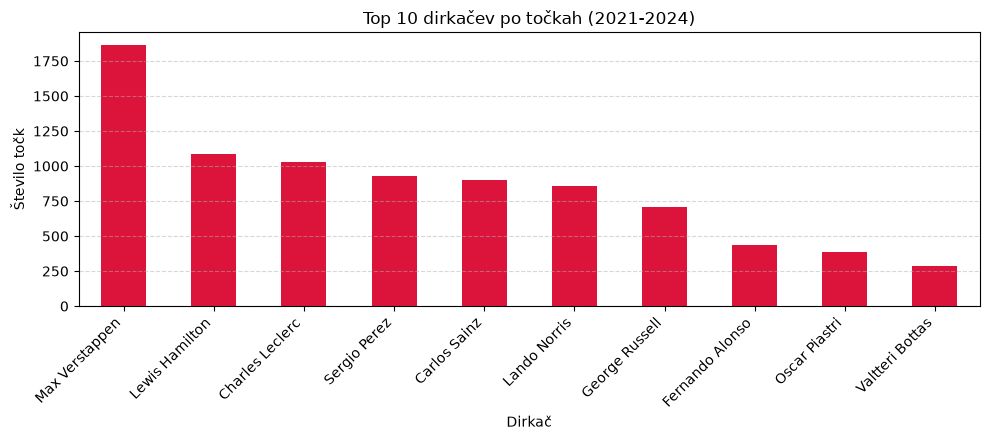

In [4]:
top_dirkaci = df.groupby("dirkac")["tocke"].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 4.5))
top_dirkaci.plot(kind="bar", color="crimson")
plt.title("Top 10 dirkačev po točkah (2021-2024)")
plt.xlabel("Dirkač")
plt.ylabel("Število točk")
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

Stolpični graf prikazuje razliko med prvim mestom ter ostalimi. Med prvim (Max Verstappen) in desetim (Valtteri Bottas) dirkačem razlika znaša več kot 1400 točk, kar kaže na veliko neenakost med dirkači na vrhu in v sredini lestvice.

### 3. Uspešnost ekip (konstruktorjev)
Poglejmo, katere ekipe so v obdobju 2021-2024 zbrala največ točk.

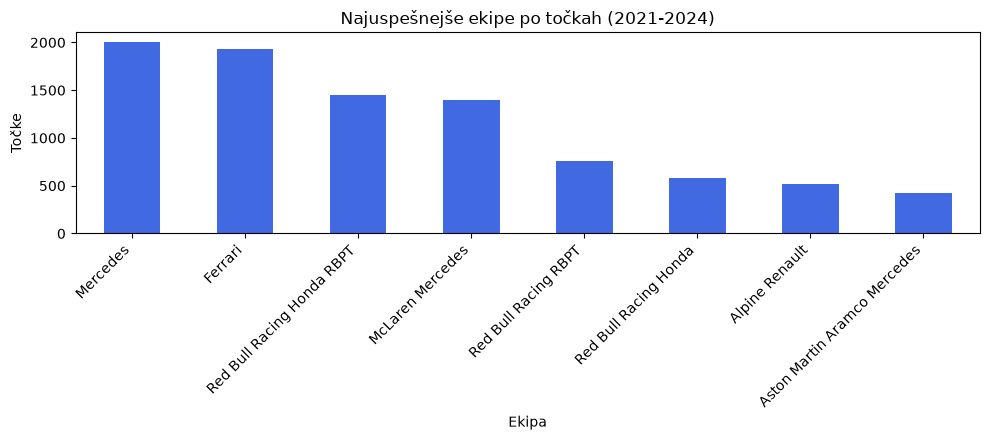

In [5]:
tocke_ekip = df.groupby("ekipa")["tocke"].sum().sort_values(ascending=False).head(8)

plt.figure(figsize=(10, 4.5))
tocke_ekip.plot(kind="bar", color="royalblue")
plt.title("Najuspešnejše ekipe po točkah (2021-2024)")
plt.xlabel("Ekipa")
plt.ylabel("Točke")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

V grafu vidimo razvrstitev ekip po zbranih točkah:

- **Mercedes in Ferrari** sta na vrhu po skupnem seštevku točk (oba z okoli 1.900 do 2.000 točkami), saj sta skozi vsa štiri leta ohranjala konstantno ime konstruktorja in dva konkurenčna dirkača.
- **Red Bull Racing** se v podatkih pojavlja pod različnimi uradnimi imeni glede na poimenovanje pogonske enote (`Red Bull Racing Honda`, `Red Bull Racing RBPT`, `Red Bull Racing Honda RBPT`), zato so njihove točke razdeljene med več vnosov.
- **Ostala moštva** srednjega in spodnjega dela lestvice osvajajo znatno manjši delež točk, kar kaže na precejšnjo tehnično razliko med vodilnimi in preostalimi ekipami.

### 4. Primerjava točk vodilnih ekip po sezonah

Poglejmo si število točk, ki so jih ekipe prejele v obravnavanem obdobju (2021-2024).

In [6]:
top_ekipe_imena = df.groupby("ekipa")["tocke"].sum().sort_values(ascending=False).head(5).index
df_ekipe = df[df["ekipa"].isin(top_ekipe_imena)]

pivot_ekipe = df_ekipe.pivot_table(index="ekipa", columns="sezona", values="tocke", aggfunc="sum", fill_value=0)
pivot_ekipe["skupaj"] = pivot_ekipe.sum(axis=1)
pivot_ekipe.sort_values(by="skupaj", ascending=False)

sezona,2021,2022,2023,2024,skupaj
ekipa,,,,,
Mercedes,613.5,515.0,409.0,468.0,2005.5
Ferrari,323.5,554.0,406.0,646.0,1929.5
Red Bull Racing Honda RBPT,0.0,0.0,860.0,589.0,1449.0
McLaren Mercedes,275.0,159.0,302.0,666.0,1402.0
Red Bull Racing RBPT,0.0,759.0,0.0,0.0,759.0


Iz tabele primerjave ekip po sezonah lahko razberemo naslednje ključne ugotovitve:

- **Mercedes in Ferrari** sta skozi vsa štiri leta ohranila visoko konstantnost in zbrala skupaj preko 1.900 točk, pri čemer je imel Ferrari svojo najmočnejšo sezono leta 2024 (646 točk).
- **Red Bull Racing** je bil točkovno najuspešnejša ekipa obravnavanega obdobja, vendar so njegove točke v uradnih podatkih razdeljene med različna poimenovanja pogonskih enot (`Red Bull Racing Honda RBPT`, `Red Bull Racing RBPT`). Zlasti v sezonah 2022 in 2023 so dosegli izjemen točkovni izkupiček.
- **McLaren** kaže izrazit trend strme rasti – od 159 točk v sezoni 2022 do kar 666 točk v sezoni 2024, s čimer so postali ena vodilnih sil prvenstva.

### 5. Delež točk po državah
Prikaz deleža osvojenih točk glede na državo, iz katere prihajajo dirkači.

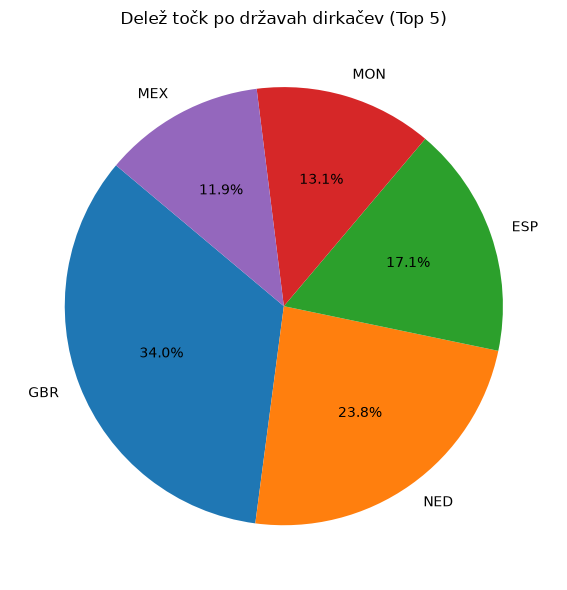

In [7]:
tocke_drzav = df.groupby("drzava")["tocke"].sum().sort_values(ascending=False).head(5)

plt.figure(figsize=(6, 6))
tocke_drzav.plot(kind="pie", autopct="%.1f%%", startangle=140)
plt.title("Delež točk po državah dirkačev (Top 5)")
plt.ylabel("")
plt.tight_layout()
plt.show()

V tortnem diagramu vidimo, da ima **Velika Britanija (GBR)** največji delež med vsemi državami, in sicer **34,0 %**, k čemur prispeva več vrhunskih dirkačev (Lewis Hamilton, Lando Norris, George Russell). Na drugem mestu je **Nizozemska (NED)** s **23,8 %**, kjer je izjemen podatek, glede na to, da je vse te točke osvojil en sam dirkač (Max Verstappen). Na tretjem mestu sledi **Španija (ESP)** s **17,1 %** (Carlos Sainz in Fernando Alonso).

### 6. Gibanje točk najboljših dirkačev skozi sezone
Poglejmo si, kako so se točke štirih vodilnih dirkačev spreminjale iz leta v leto.

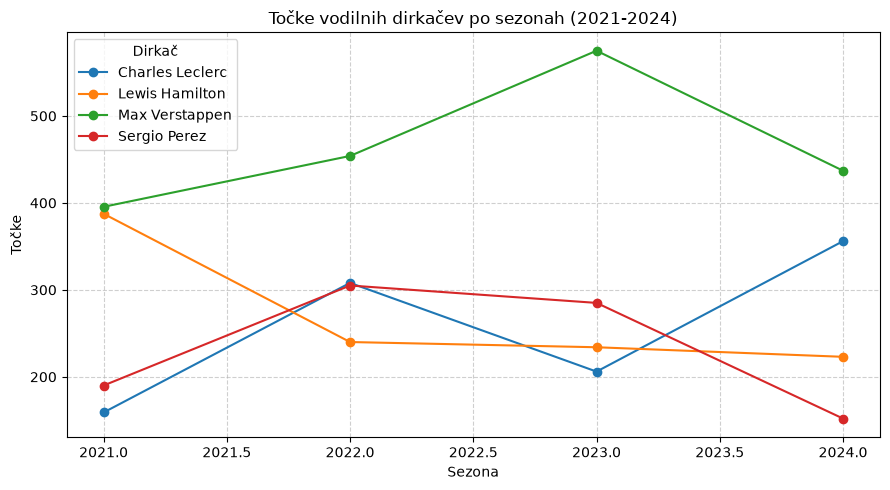

In [8]:
top_4_imena = df.groupby("dirkac")["tocke"].sum().sort_values(ascending=False).head(4).index
df_top4 = df[df["dirkac"].isin(top_4_imena)]

pivot_dirkaci = df_top4.pivot_table(index="sezona", columns="dirkac", values="tocke", fill_value=0)

plt.figure(figsize=(9, 5))
pivot_dirkaci.plot(kind="line", marker="o", ax=plt.gca())
plt.title("Točke vodilnih dirkačev po sezonah (2021-2024)")
plt.xlabel("Sezona")
plt.ylabel("Točke")
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend(title="Dirkač")
plt.tight_layout()
plt.show()

Črtni graf prikazuje, kako sta bila Max Verstappen in Lewis Hamilton v sezoni 2021 točkovno skoraj izenačena. V sezonah 2022 in 2023 pa je Verstappen močno prevzel prevlado. V sezoni 2024 pa se je Verstappnu približal Leclerc.

### 7. Povezava med končnim mestom in osvojenimi točkami
Poglejmo točkasti diagram (scatter plot), ki prikazuje, kako točke eksponentno padajo z uvrstitvijo proti koncu lestvice, pri čemer so točke obarvane glede na sezono.

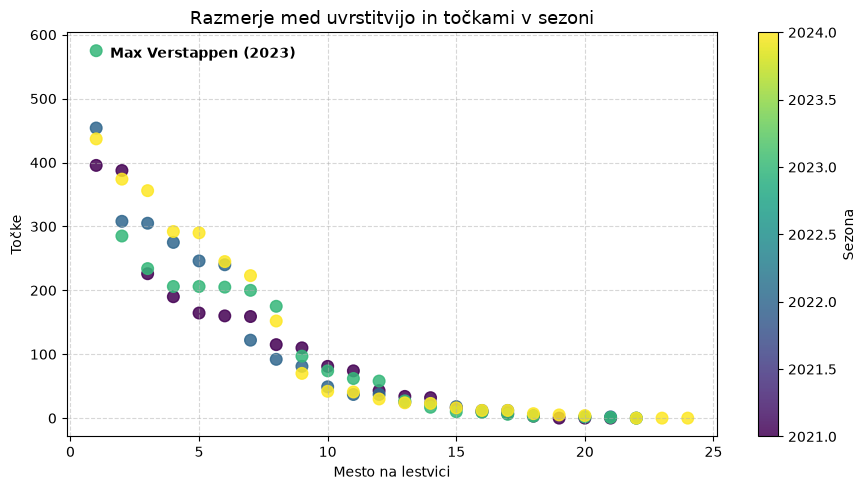

In [9]:
plt.figure(figsize=(9, 5))
plt.scatter(df["mesto"], df["tocke"], c=df["sezona"], cmap="viridis", s=70, alpha=0.85)
plt.colorbar(label="Sezona")
plt.title("Razmerje med uvrstitvijo in točkami v sezoni", fontsize=13)
plt.xlabel("Mesto na lestvici")
plt.ylabel("Točke")
plt.grid(True, linestyle="--", alpha=0.5)

# Označimo rekordni dosežek
rekord = df.loc[df["tocke"].idxmax()]
plt.annotate(
    f"{rekord['dirkac']} ({rekord['sezona']})",
    (rekord["mesto"], rekord["tocke"]),
    textcoords="offset points",
    xytext=(10, -5),
    fontweight="bold"
)

plt.tight_layout()
plt.show()

Iz točkastega diagrama je razvidno, da točkovni sistem Formule 1 močno nagrajuje prva mesta (strma krivulja navzgor), medtem ko so uvrstitve od 10. mesta naprej točkovno zelo blizu ničli. Izstopa točka na vrhu, ki predstavlja rekordno število točk Maxa Verstappna v sezoni 2023.

## Zaključek
Ta projektna naloga je dala zanimiv vpogled v rezultate Formule 1 med letoma 2021 in 2024. Ugotovili smo, da je med dirkači daleč največ točk osvojil Max Verstappen, pri državah pa so največji delež točk zbrali britanski dirkači. Videli smo, da sta Mercedes in Ferrari skozi vsa štiri leta ohranjala podobno število točk, McLaren pa je imel v sezoni 2024 velik skok. Prav tako smo na grafih pokazali, kako so se točke spreminjale po sezonah in kako točkovni sistem nagrajuje samo prvih deset mest.